In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from collections import deque
import os
import shutil 
import math
import datetime as dt
import random

In [2]:
from sklearn.model_selection import train_test_split
from keras.layers import *
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [3]:
import cv2
import matplotlib.pyplot as plt

def play_video(video_path, n_frames=16):  #name to be cchanged to preview
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError("Couldn't open video")

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.ravel()

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total // n_frames, 1)

    for i in range(n_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[i].imshow(frame)
        axes[i].axis("off")

    cap.release()
    plt.tight_layout()

In [4]:
#  classes directories
violence_dir ="../data/violence_fight_detection_dataset/RLVS/train/Fight/"
non_violence_dir ="../data/violence_fight_detection_dataset/RLVS/train/NonFight/"

# retrive list of all the vid files present in the class directory
non_violence_files_names_list = os.listdir(non_violence_dir)
violence_files_names_list = os.listdir(violence_dir)

# randomly select a vid file in from the classes directory
random_nonviolence_vid = random.choice(non_violence_files_names_list)
random_violence_vid = random.choice(violence_files_names_list)

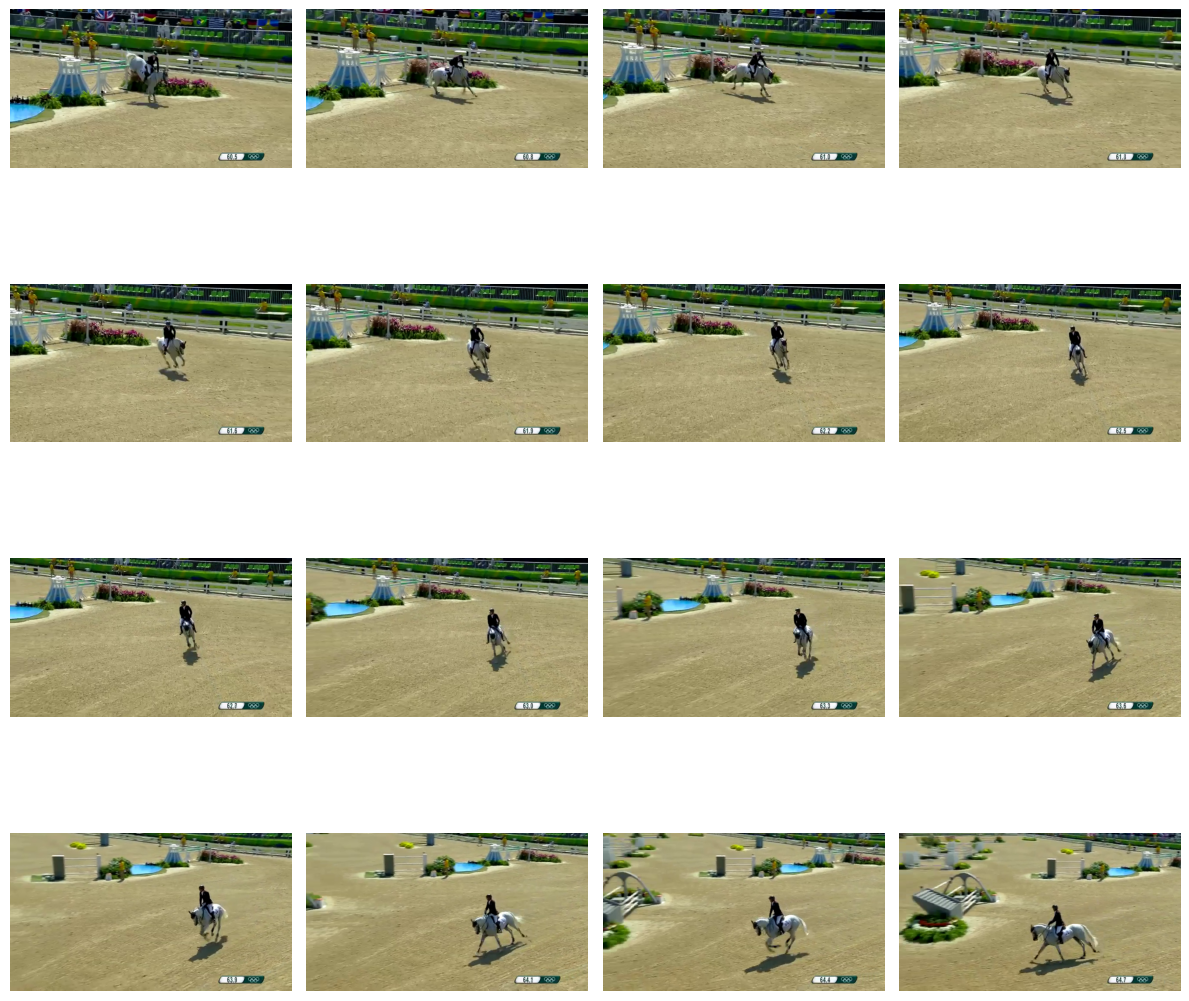

In [5]:
play_video(f"{non_violence_dir}/{random_nonviolence_vid}")

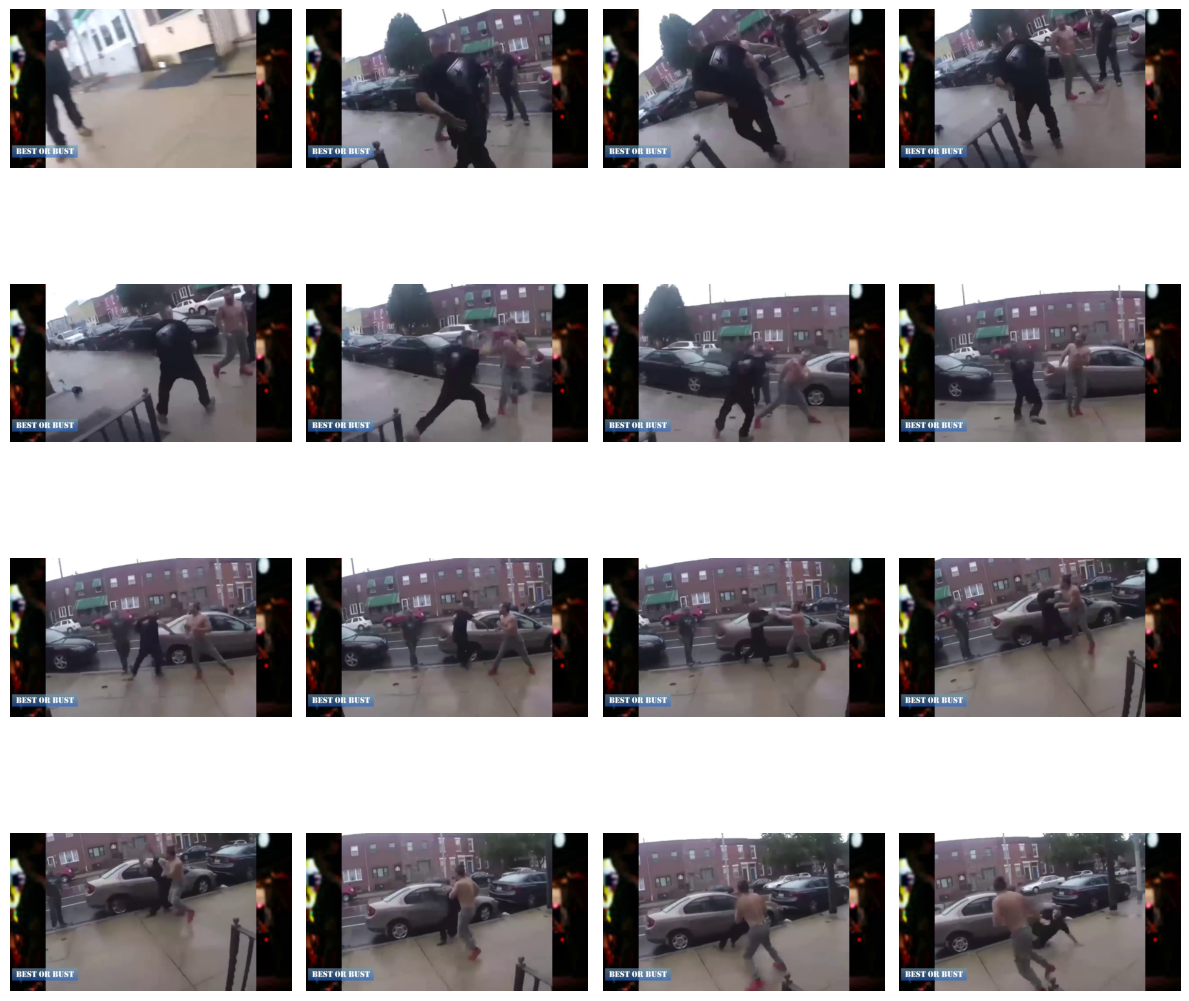

In [6]:
play_video(f"{violence_dir}/{random_violence_vid}")

## Extracting Frames

In [7]:
IMAGE_HEIGHT , IMAGE_WIDTH = 64 , 64

# no of frames of a video that will be fed to the modes as one sequence
SEQUENCE_LENGTH = 16

DATASET_DIR = "../data/violence_fight_detection_dataset/RLVS/train/"

CLASSES_LIST = ['NonFight','Fight']

In [8]:
import imageio

def frames_extraction(video_path):
    frames_list=[]
    try:
        reader = imageio.get_reader(video_path,"ffmpeg")
        num_frames = reader.count_frames()
        skip_frames_window = max(int(num_frames/SEQUENCE_LENGTH),1)

        for frame_counter in range(0,num_frames,skip_frames_window):
            ''' resizes the frame in the means of heiight & width and also sequence length'''
            frame = reader.get_data(frame_counter)
            frame = cv2.resize(frame,(IMAGE_HEIGHT,IMAGE_WIDTH))
            frame = frame / 255.0
            frames_list.append(frame)
            if len(frames_list) == SEQUENCE_LENGTH:
                break
        reader.close()
    except Exception as e:
        print(f"Error processing {video_path}:{e}")
    return frames_list

In [9]:
def create_dataset():
    '''provides features , labels , video file paths for for each file  if the sequence lenght is valid'''
    features=[]
    labels=[]
    video_files_paths=[]

    for class_index , class_name in enumerate(CLASSES_LIST):
        print(f'Extracting Data of Class: {class_name}')

        files_list = os.listdir(os.path.join(DATASET_DIR,class_name))

        for file_name in files_list:

            video_file_path = os.path.join(DATASET_DIR,class_name,file_name)

            frames = frames_extraction(video_file_path)

            if len(frames) == SEQUENCE_LENGTH:

                # appending data to their respective lists
                features.append(frames)
                labels.append(class_index)
                video_files_paths.append(video_file_path)

    features = np.asarray(features)
    labels = np.array(labels)
    return features , labels , video_files_paths


In [10]:
# creating dataset:

features , labels , video_files_paths = create_dataset()

Extracting Data of Class: NonFight


The frame size for reading (1080, 1920) is different from the source frame size (1920, 1080).
The frame size for reading (1080, 1920) is different from the source frame size (1920, 1080).
The frame size for reading (1080, 1920) is different from the source frame size (1920, 1080).
The frame size for reading (1080, 1920) is different from the source frame size (1920, 1080).


Error processing ../data/violence_fight_detection_dataset/RLVS/train/NonFight\file_003043.mp4:105


The frame size for reading (1080, 1920) is different from the source frame size (1920, 1080).
The frame size for reading (1080, 1920) is different from the source frame size (1920, 1080).


Extracting Data of Class: Fight


In [11]:
# saving the extracted data
np.save("features.npy",features)
np.save("labels.npy",labels)
np.save("video_files_paths.npy",video_files_paths)

In [12]:
# Convert labels into one hot encoded vectors
one_hot_encoded_labels = to_categorical(labels)

In [13]:
features_train , features_test , labels_train , labels_test = train_test_split(features , one_hot_encoded_labels , test_size = 0.1 , shuffle = True , random_state = 42)

In [14]:
print(features_train.shape , labels_train.shape)
print(features_test.shape , labels_test.shape)

(1439, 16, 64, 64, 3) (1439, 2)
(160, 16, 64, 64, 3) (160, 2)


## Importing and Fine-Tuning MobileNet

In [15]:
from keras.applications.mobilenet_v2 import MobileNetV2
mobilenet = MobileNetV2(include_top=False , weights='imagenet')

# fine-tuning

mobilenet.trainable=True
for layer in mobilenet.layers[:-40]:
    layer.trainable=False



In [16]:
mobilenet.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 Conv1 (Conv2D)                 (None, None, None,   864         ['input_1[0][0]']                
                                32)                                                               
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, None, None,   128         ['Conv1[0][0]']                  
                                32)                                            

## Building Model

In [17]:
def create_model():
    model = Sequential()
    model.add(Input(shape=(SEQUENCE_LENGTH , IMAGE_HEIGHT , IMAGE_WIDTH , 3)))

    # passing the mobilenet in the timedistributed layer to handle the sequence
    model.add(TimeDistributed(mobilenet))

    model.add(Dropout(0.25))

    model.add(TimeDistributed(Flatten()))

    lstm_fw = LSTM(units=32)
    lstm_bw = LSTM(units=32 , go_backwards=True)
    
    model.add(Bidirectional(lstm_fw,backward_layer=lstm_bw))

    model.add(Dropout(0.25))
    
    model.add(Dense(256,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(128,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(64,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(32,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(len(CLASSES_LIST),activation='softmax'))
    
    model.summary()

    return model


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  (None, 16, 2, 2, 1280)   2257984   
 ibuted)                                                         
                                                                 
 dropout (Dropout)           (None, 16, 2, 2, 1280)    0         
                                                                 
 time_distributed_1 (TimeDis  (None, 16, 5120)         0         
 tributed)                                                       
                                                                 
 bidirectional (Bidirectiona  (None, 64)               1319168   
 l)                                                              
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                        

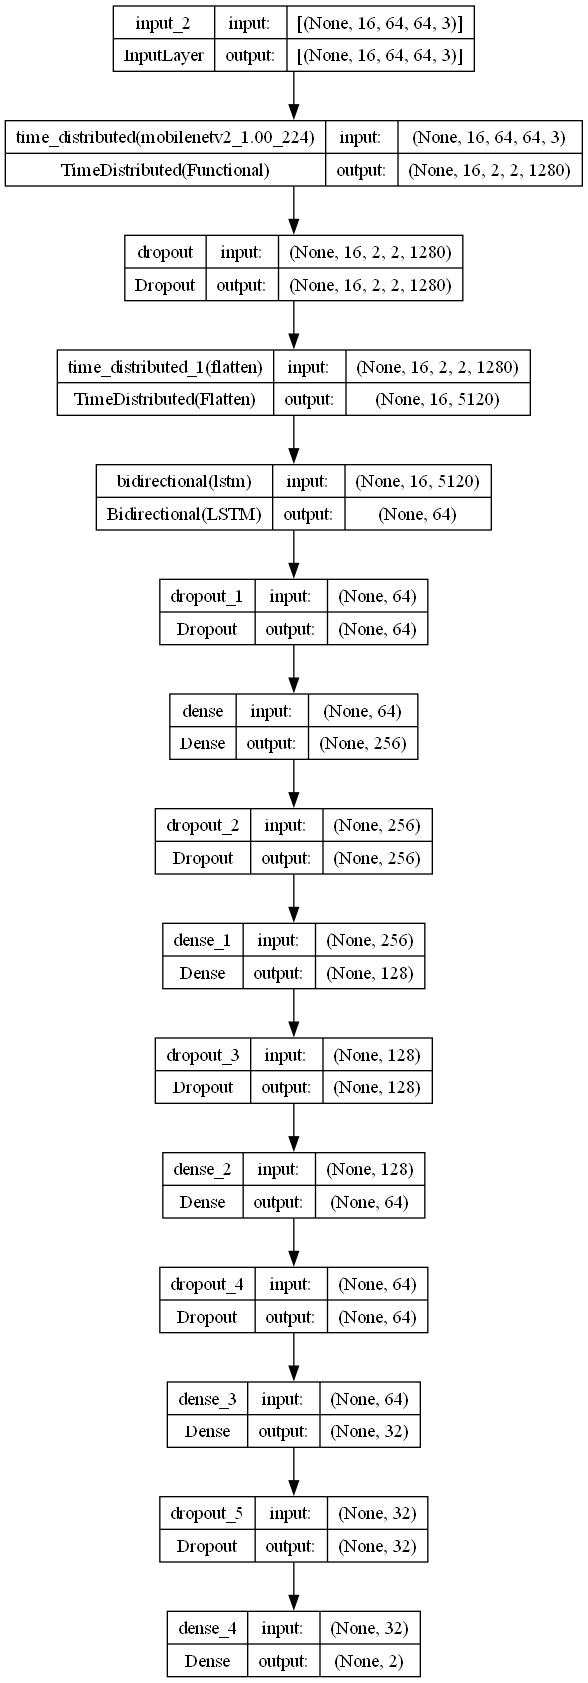

In [18]:
# Constructing the model

MoBiLSTM_model = create_model()

plot_model(MoBiLSTM_model,to_file = 'MoBiLSTM_model_structure_plot.png' , show_shapes=True , show_layer_names=True)

In [19]:
# specifying callbacks and fittings

early_stopping_callback = EarlyStopping(monitor='val_accuracy', patience = 10 , restore_best_weights=True)

# reducing overfitting by decreasing learning on reduceonplateau callback
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor = 0.6 ,
    patience = 5 , 
    min_lr = 0.00005,
    verbose =1
)

# compiling model
MoBiLSTM_model.compile(loss = 'categorical_crossentropy', optimizer='sgd',metrics=['accuracy'])

# fitting the model
MobBiLSTM_model_history = MoBiLSTM_model.fit(
    x=features_train,
    y=labels_train,
    epochs=20,
    batch_size=8,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback, reduce_lr]
)

Epoch 1/20
144/144 [==============================] - 38s 105ms/step - loss: 0.6979 - accuracy: 0.4944 - val_loss: 0.6915 - val_accuracy: 0.5174 - lr: 0.0100
Epoch 2/20
144/144 [==============================] - 9s 63ms/step - loss: 0.6849 - accuracy: 0.5361 - val_loss: 0.6887 - val_accuracy: 0.5104 - lr: 0.0100
Epoch 3/20
144/144 [==============================] - 8s 59ms/step - loss: 0.6807 - accuracy: 0.5552 - val_loss: 0.6598 - val_accuracy: 0.6667 - lr: 0.0100
Epoch 4/20
144/144 [==============================] - 7s 51ms/step - loss: 0.6370 - accuracy: 0.6368 - val_loss: 0.5837 - val_accuracy: 0.7083 - lr: 0.0100
Epoch 5/20
144/144 [==============================] - 7s 48ms/step - loss: 0.5186 - accuracy: 0.7750 - val_loss: 0.4506 - val_accuracy: 0.8021 - lr: 0.0100
Epoch 6/20
144/144 [==============================] - 7s 48ms/step - loss: 0.4248 - accuracy: 0.8367 - val_loss: 0.3492 - val_accuracy: 0.8646 - lr: 0.0100
Epoch 7/20
144/144 [==============================] - 7s 45ms/

In [20]:
model_evaluation_history = MoBiLSTM_model.evaluate(features_test, labels_test)

5/5 [==============================] - 2s 41ms/step - loss: 0.4387 - accuracy: 0.8750


## Model Evaluation

In [21]:
def plot_metric(model_training_history , metric_name_1, metric_name_2 , plot_name):

    metric_value_1 = model_training_history.history[metric_name_1]
    metric_value_2 = model_training_history.history[metric_name_2]

    # Get the Epochs count
    epochs = range(len(metric_value_1))

    plt.plot(epochs , metric_value_1, 'blue', label= metric_name_1)
    plt.plot(epochs , metric_value_2, 'red', label= metric_name_2)

    plt.title(str(plot_name))

    plt.legend()

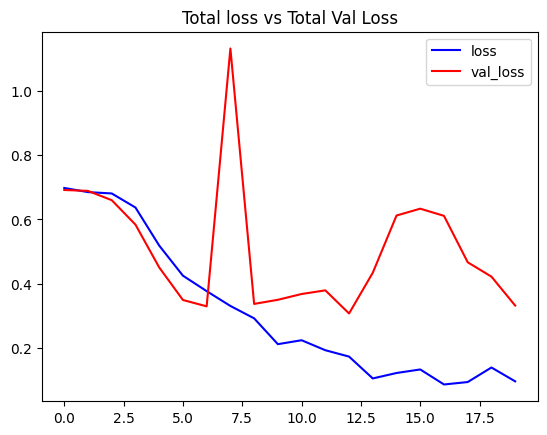

In [26]:
plot_metric(MobBiLSTM_model_history, 'loss','val_loss','Total loss vs Total Val Loss' )

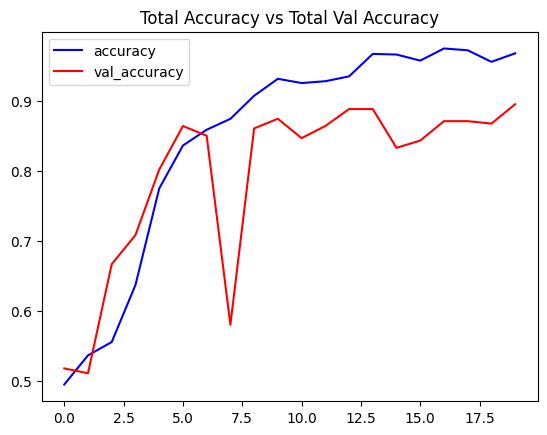

In [27]:
plot_metric(MobBiLSTM_model_history, 'accuracy','val_accuracy','Total Accuracy vs Total Val Accuracy' )

## Test Set


In [29]:
labels_predict = MoBiLSTM_model.predict(features_test)

5/5 [==============================] - 1s 31ms/step


In [30]:
# decoding data to use in metrics
labels_predict = np.argmax(labels_predict , axis=1)
labels_test_normal = np.argmax(labels_test,axis=1)

In [31]:
labels_test_normal.shape , labels_predict.shape

((160,), (160,))

## Accuracy Score

In [33]:
from sklearn.metrics import accuracy_score
AccScore = accuracy_score(labels_predict,labels_test_normal)
print('Accuracy:', AccScore)

Accuracy: 0.875


## Confusion Matrix

## Confusion Matrix

[Text(0, 0.5, 'Non Violence'), Text(0, 1.5, 'Violence')]

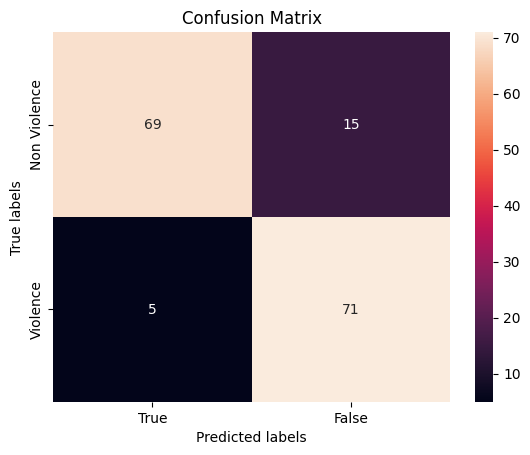

In [41]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

ax = plt.subplot()
cm = confusion_matrix(labels_test_normal,labels_predict)
sns.heatmap(cm,annot=True,fmt='g',ax=ax)

ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['True','False'])
ax.yaxis.set_ticklabels(['Non Violence','Violence'])

In [42]:
from sklearn.metrics import classification_report
ClassificationReport = classification_report(labels_test_normal,labels_predict)
print('Classification Report:',ClassificationReport)

Classification Report:               precision    recall  f1-score   support

           0       0.93      0.82      0.87        84
           1       0.83      0.93      0.88        76

    accuracy                           0.88       160
   macro avg       0.88      0.88      0.87       160
weighted avg       0.88      0.88      0.87       160



In [43]:
MoBiLSTM_model.save('MobBiLSTM_model.h5')